In [1]:
# Cell 1 — Imports & constants
import sys; sys.path.insert(0, '.')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pymc as pm
import arviz as az
from astropy.coordinates import get_sun
from astropy.time import Time
from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, LW_STANDARD, LW_STRONG,
    PRIMARY_COLOR, SECONDARY_COLOR, TERTIARY_COLOR, NEUTRAL_COLOR,
    SCATTER_S_FINE, SCATTER_S_STANDARD,
)

C_LIGHT      = 2.99792458e8     # m/s
NCH_LON_DEG  = -122.2573        # NCH longitude [deg east]
BAD_CHANNELS = [0, 256, 512, 768]
SB_LO, SB_HI = 447, 848        # signal band (inclusive)
N_CH_SUB     = 50               # channels used in MCMC (evenly spaced in signal band)

def _ha_fmt(deg, pos=None):
    """Format decimal degrees as LaTeX $±HH^h MM^m$ (hour angle, no seconds)."""
    sign = '-' if deg < 0 else '+'
    h_abs = abs(deg) / 15.0
    hh = int(h_abs)
    mm = round((h_abs - hh) * 60)
    if mm == 60:
        hh += 1; mm = 0
    return rf'${sign}{hh}^h\,{mm:02d}^m$'

HA_FMT = mticker.FuncFormatter(_ha_fmt)

# Baseline estimation from Sun fringe data

## 1. Interferometer geometry

A two-element interferometer measures the **cross-correlation** (complex visibility) between the voltages $v_1(t)$ and $v_2(t)$ received at two dishes separated by baseline vector $\mathbf{b}$. For a point source in direction $\hat{s}$, the geometric path-length difference between the two dishes is

$$\Delta\ell = \mathbf{b}\cdot\hat{s}$$

giving a **geometric delay**

$$\tau_g = \frac{\mathbf{b}\cdot\hat{s}}{c}$$

For a purely **east–west baseline** $B_{\rm ew}$ at a site with latitude $\phi$, the dot product with the unit vector to a source at declination $\delta$ and hour angle $H$ evaluates to

$$\boxed{\tau_g = \frac{B_{\rm ew}}{c}\cos\delta\,\sin H}$$

The $\cos\delta$ factor projects the baseline onto the equatorial plane, and $\sin H$ gives the component along the east–west direction as the source rises and sets. There is no north–south or vertical contribution for a purely E–W baseline.

---

## 2. Complex visibility and the fringe pattern

The complex cross-spectrum at sky frequency $f$ is

$$V_{12}(f) = A(f)\,e^{\,i\phi(f)}$$

where $A(f)$ is the correlated amplitude (source brightness times system response) and the **interferometric phase** is

$$\phi(f) = 2\pi f\,\tau_{\rm tot} = 2\pi f\!\left(\tau_g + \tau_0\right)$$

with $\tau_0$ a constant instrumental delay (cable length mismatch, etc.). Substituting $\tau_g$:

$$\phi(f,\,H) = \frac{2\pi f\,B_{\rm ew}}{c}\cos\delta\,\sin H + 2\pi f\,\tau_0$$

The real part of $V_{12}$ is a **sinusoidal fringe** in hour angle:

$$\mathrm{Re}(V_{12}) = A(f)\cos\!\left[\frac{2\pi f\,B_{\rm ew}}{c}\cos\delta\,\sin H + 2\pi f\,\tau_0\right]$$

---

## 3. Fringe rate and baseline–frequency duality

Differentiating the phase with respect to $H$:

$$\frac{d\phi}{dH} = \frac{2\pi f\,B_{\rm ew}}{c}\cos\delta\,\cos H$$

The **instantaneous fringe rate** (cycles per radian of HA) is therefore

$$\nu_{\rm fr}(H) = \frac{1}{2\pi}\frac{d\phi}{dH} = \frac{f\,B_{\rm ew}}{c}\cos\delta\,\cos H$$

Key observations:
- Fringe rate scales **linearly with both $f$ and $B_{\rm ew}$** — longer baselines or higher frequencies produce faster fringes.
- It vanishes at $H = \pm 90°$ (source on the meridian-perpendicular) and is maximum at transit ($H = 0$).
- Over our narrow 6° span at $H \approx -72°$, $\cos H$ changes by $<1\%$, so the fringe rate is approximately constant and the pattern looks like a pure sinusoid in HA.

The FFT of $\mathrm{Re}(V_{12})$ vs time gives the dominant fringe frequency $f_{\rm fr}$, from which the baseline can be estimated:

$$B_{\rm ew} = \frac{c\,f_{\rm fr}}{f\,\cos\delta\,\cos H_{\rm mid}}$$

---

## 4. DC offset and its removal

In practice, $V_{12}$ contains a DC bias from imperfect correlation (e.g.\ cross-talk, LO leakage). This appears as a non-zero mean of $\mathrm{Re}(V_{12})$ across captures. It is removed per channel:

$$V_{\rm dc}(n,k) = V_{12}(n,k) - \langle\,\mathrm{Re}(V_{12})\rangle_n$$

The DC-corrected visibility $V_{\rm dc}$ isolates the oscillatory fringe component used for baseline fitting.

---

## 5. Per-frequency phase model for MCMC

Fitting across $N_{\rm ch}$ frequency channels simultaneously strongly constrains $B_{\rm ew}$ and $\tau_0$ because the phase at each channel must be consistent with the **same** geometric delay $\tau_g(n)$. The model at channel $k$ (sky frequency $f_k$) and capture $n$ is:

$$\varphi_{\rm model}(n,k) = 2\pi f_k\!\left(\frac{B_{\rm ew}}{c}\cos\delta\,\sin H_n + \tau_0\right)$$

with parameters:

| Symbol | Description |
|---|---|
| $B_{\rm ew}$ | East–west physical baseline [m] |
| $\tau_0$ | Constant instrumental delay offset [s] (absorbs cable mismatch) |
| $\kappa$ | Von Mises concentration (phase SNR; $\sigma_\varphi \approx \kappa^{-1/2}$ for large $\kappa$) |

In [2]:
# Cell 2 — Load DC-corrected data (new session only)
# Mirrors the data-loading pattern from diagnostic_sun.ipynb

DATA_DIR = Path('../../data/lab03/archive/sun_calibration')

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {len(files)} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')

# --- Sort by midpoint unix time -------------------------------------------
def _mid_unix(f):
    if 'unix_time_start' in f and 'unix_time_end' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[j] for j in order]

# --- Compute LST, Sun RA, HA ----------------------------------------------
def _lst_deg(unix_t):
    """Approximate local sidereal time at NCH longitude."""
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    return get_sun(Time(unix_t, format='unix')).ra.deg

lst_arr    = np.array([_lst_deg(t)    for t in unix_sort])
sun_ra_arr = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg     = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

# Read declination from file metadata; fall back to astropy if nan
_dec_raw = float(files_s[0]['dec_deg']) if 'dec_deg' in files_s[0] else float('nan')
if np.isnan(_dec_raw):
    # Compute Sun declination at the session midpoint using astropy
    _t_mid = Time(unix_sort[len(unix_sort)//2], format='unix')
    dec_deg = get_sun(_t_mid).dec.deg
else:
    dec_deg = _dec_raw
print(f'Sun dec  : {dec_deg:.4f} deg')
print(f'HA range : {ha_deg.min():.2f} -> {ha_deg.max():.2f}  ({ha_deg.max()-ha_deg.min():.2f} deg span)')

# --- DC correction --------------------------------------------------------
corr_matrix = np.array([f['corr'].astype(complex) for f in files_s])  # (N_cap, N_CH)
corr_matrix[:, BAD_CHANNELS] = np.nan

re_mean = np.nanmean(corr_matrix.real, axis=0)          # per-channel DC
corr_dc = corr_matrix - re_mean[np.newaxis, :]           # subtract DC from Re

# Amplitude peak for normalisation reference (for plots)
AMP_PEAK = np.nanmax(np.abs(corr_dc))
print(f'DC-corr peak : {AMP_PEAK:.4f}')
print(f'N_cap={corr_dc.shape[0]},  N_CH={corr_dc.shape[1]}')

Loaded 124 captures  |  9.7900 -- 10.0398 GHz  |  244.1 kHz/ch
Sun dec  : -0.9256 deg
HA range : -74.91 -> -68.68  (6.24 deg span)
DC-corr peak : 0.6279
N_cap=124,  N_CH=1024


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_69835/1675260144.py:64: RuntimeWarning: Mean of empty slice
  re_mean = np.nanmean(corr_matrix.real, axis=0)          # per-channel DC


In [3]:
# Cell 3 — Quick FFT baseline estimate (sanity check)
# For 3 evenly-spaced good signal-band channels, find the dominant fringe
# frequency and back-calculate B_ew.

OMEGA_EARTH = 2 * np.pi / 86164.09054   # Earth's sidereal rotation rate [rad/s]

# Pick 3 channels evenly spaced in signal band, excluding bad channels
ch_all_sb = [k for k in range(SB_LO, SB_HI + 1) if k not in BAD_CHANNELS]
check_idx = [ch_all_sb[len(ch_all_sb) // 4],
             ch_all_sb[len(ch_all_sb) // 2],
             ch_all_sb[3 * len(ch_all_sb) // 4]]

ha_rad_fft = np.deg2rad(ha_deg)
HA_mid     = np.deg2rad(np.mean(ha_deg))
dec_rad    = np.deg2rad(dec_deg)

# Time axis from HA (uniform ≈ ok over 6°)
t_axis = ha_rad_fft / OMEGA_EARTH   # seconds (relative)
t_axis -= t_axis.mean()
dt_mean = np.mean(np.diff(t_axis))

print(f'FFT check  —  dt_mean={dt_mean:.2f} s,  HA_mid={np.rad2deg(HA_mid):.2f} deg')
print(f'{"Channel":>8}  {"f_sky [GHz]":>14}  {"f_fringe [mHz]":>16}  {"B_ew [m]":>12}')

B_fft_estimates = []
for k in check_idx:
    z_k = corr_dc[:, k]
    # Use real part (fringe oscillation)
    signal = np.nan_to_num(z_k.real, nan=0.0)
    N = len(signal)
    freqs = np.fft.rfftfreq(N, d=dt_mean)              # [Hz]
    power = np.abs(np.fft.rfft(signal))**2
    # Ignore DC
    power[0] = 0.0
    f_fr = freqs[np.argmax(power)]                      # dominant fringe freq [Hz]
    
    # B_ew = f_fr × λ / (Ω_E × cos(dec) × cos(HA_mid))
    lam = C_LIGHT / (F_SKY_GHZ[k] * 1e9)               # wavelength [m]
    denom = OMEGA_EARTH * np.cos(dec_rad) * np.cos(HA_mid)
    B_ew_fft = lam * f_fr / denom
    B_fft_estimates.append(B_ew_fft)
    print(f'{k:>8}  {F_SKY_GHZ[k]:>14.6f}  {f_fr*1e3:>16.4f}  {B_ew_fft:>12.4f}')

B_fft_mean = np.mean(B_fft_estimates)
print(f'\nMean FFT B_ew estimate: {B_fft_mean:.3f} m  '
      f'(spread: {np.ptp(B_fft_estimates):.3f} m)')

FFT check  —  dt_mean=12.13 s,  HA_mid=-71.67 deg
 Channel     f_sky [GHz]    f_fringe [mHz]      B_ew [m]
     548        9.923789           13.9560       18.3861
     648        9.948203           13.9560       18.3409
     748        9.972617           13.9560       18.2960

Mean FFT B_ew estimate: 18.341 m  (spread: 0.090 m)


In [4]:
# Cell 4 — Prepare MCMC data arrays (phase)

# Select N_CH_SUB channels evenly from signal band, excluding bad channels
ch_all  = [k for k in range(SB_LO, SB_HI+1) if k not in BAD_CHANNELS]
stride  = max(1, len(ch_all) // N_CH_SUB)
ch_idx  = np.array(ch_all[::stride][:N_CH_SUB])   # N_CH_SUB channels
f_sub   = F_SKY_GHZ[ch_idx] * 1e9                  # Hz, shape (N_CH_SUB,)

print(f'Using {len(ch_idx)} channels:  '
      f'{F_SKY_GHZ[ch_idx[0]]:.4f} -- {F_SKY_GHZ[ch_idx[-1]]:.4f} GHz')

# DC-corrected visibilities at selected channels, shape (N_cap, N_CH_SUB)
vis_sub = corr_dc[:, ch_idx]

# Phase of each (capture, channel) — no amplitude normalisation needed
# np.angle returns values in [-π, π]
phase_obs = np.angle(vis_sub).astype(np.float64)   # (N_cap, N_CH_SUB)

# Geometry arrays
ha_rad  = np.deg2rad(ha_deg)           # (N_cap,)
dec_rad = np.deg2rad(dec_deg)          # scalar
cos_dec = float(np.cos(dec_rad))
sin_ha  = np.sin(ha_rad)               # (N_cap,)

print(f'phase_obs shape: {phase_obs.shape}')
print(f'cos(dec)={cos_dec:.6f}')
print(f'phase_obs range: [{phase_obs.min():.3f}, {phase_obs.max():.3f}] rad  '
      f'(expected [-π, π] = [-3.14, 3.14])')

Using 50 channels:  9.8991 -- 9.9953 GHz
phase_obs shape: (124, 50)
cos(dec)=0.999870
phase_obs range: [-3.139, 3.141] rad  (expected [-π, π] = [-3.14, 3.14])


## Bayesian model: phase-based baseline estimation

### Physical model

For a two-dish east–west interferometer at latitude $\phi$, the geometric delay to a source at declination $\delta$ and hour angle $H_n$ is

$$\tau_g(n) = \frac{B_{\rm ew}}{c}\cos\delta\,\sin H_n$$

Including a constant instrumental cable-delay offset $\tau_0$, the total delay is

$$\tau_{\rm tot}(n) = \tau_g(n) + \tau_0$$

The predicted interferometric phase at sky frequency $f_k$ and capture $n$ is

$$\varphi_{\rm model}(n,k) = 2\pi f_k\,\tau_{\rm tot}(n) = 2\pi f_k \left(\frac{B_{\rm ew}}{c}\cos\delta\,\sin H_n + \tau_0\right)$$

### Likelihood

The observed phase $\varphi_{\rm obs}(n,k) = \arg V_{\rm dc}(n,k) \in [-\pi,\pi]$ is modelled as a **Von Mises** random variable — the natural circular analogue of the Gaussian, which handles phase wrapping automatically:

$$\varphi_{\rm obs}(n,k) \sim \mathrm{VonMises}\!\left(\mu = \varphi_{\rm model}(n,k),\; \kappa\right)$$

The concentration $\kappa$ plays the role of a precision: for high SNR ($\kappa \gg 1$) the Von Mises approaches a Gaussian with standard deviation $\sigma_\varphi \approx 1/\sqrt{\kappa}$. The amplitude $A$ drops out of the likelihood entirely.

The log-likelihood (up to constants) is

$$\ln \mathcal{L} = \kappa \sum_{n,k} \cos\!\left[\varphi_{\rm obs}(n,k) - \varphi_{\rm model}(n,k)\right]$$

### Priors

| Parameter | Prior | Rationale |
|---|---|---|
| $B_{\rm ew}$ [m] | $\mathrm{TruncatedNormal}(\mu=10,\,\sigma=5,\,{\rm lower}=0)$ | Centred on FFT estimate; $\sigma=5$ m is broad but informative; truncated at 0 to enforce positivity |
| $\tau_0$ [ns] | $\mathrm{Normal}(0,\,10)$ | Zero-centred; $\pm$10 ns covers $\sim$3 m cable mismatch |
| $\kappa$ | $\mathrm{HalfNormal}(\sigma=10)$ | Positive concentration; weakly informative on phase noise scale |

In [5]:
# Cell 5 — PyMC NUTS model — Von Mises phase likelihood
#
# Physical model:
#   τ_g(n)        = (B_ew / c) × cos(δ) × sin(H_n)   geometric delay [s]
#   τ_tot(n)      = τ_g(n) + τ_0                      + instrumental offset
#   φ_model(n,k)  = 2π × f_k × τ_tot(n)              predicted phase [rad]
#
# Likelihood (Von Mises — circular analogue of Normal, handles wrapping):
#   φ_obs(n,k) ~ VonMises(μ=φ_model(n,k), κ)
#
# κ is the concentration: large κ ↔ low phase noise.
# Amplitude A drops out entirely — no nuisance parameter needed.

with pm.Model() as fringe_model:
    # ── Priors ────────────────────────────────────────────────────────────────
    # B_ew: east-west baseline [m].
    # Normal centred at 10 m (consistent with FFT estimate), σ=5 m.
    # Truncated to positive values via pm.Truncated to enforce physicality.
    B_ew = pm.TruncatedNormal("B_ew", mu=10.0, sigma=5.0, lower=0.0)

    # tau_0: constant instrumental/cable delay mismatch [ns].
    # ±10 ns covers plausible cable length differences (~3 m).
    tau_0_ns = pm.Normal("tau_0_ns", mu=0.0, sigma=10.0)   # [ns]
    tau_0    = tau_0_ns * 1e-9                               # [s]

    # kappa: Von Mises concentration (= 1/σ_φ² for small noise).
    # HalfNormal weakly-informative; kappa~1 means σ_φ~1 rad (noisy),
    # kappa~10 means σ_φ~0.3 rad (moderate SNR).
    kappa = pm.HalfNormal("kappa", sigma=10.0)

    # ── Forward model ─────────────────────────────────────────────────────────
    # Geometric delay per capture [s]:  shape (N_cap,)
    tau_g   = (B_ew / C_LIGHT) * cos_dec * sin_ha   # (N_cap,)
    tau_tot = tau_g + tau_0                           # (N_cap,)

    # Predicted phase at each (capture, channel) [rad]:  shape (N_cap, N_CH_SUB)
    phase_model = 2.0 * np.pi * tau_tot[:, None] * f_sub[None, :]

    # ── Likelihood ────────────────────────────────────────────────────────────
    # Von Mises handles the [-π, π] wrapping automatically.
    pm.VonMises("phase_obs", mu=phase_model, kappa=kappa, observed=phase_obs)

# Sample with NUTS
with fringe_model:
    try:
        idata = pm.sample(
            draws=2000,
            tune=1000,
            chains=4,
            target_accept=0.9,
            nuts_sampler="numpyro",
            random_seed=42,
            return_inferencedata=True,
        )
    except Exception as e:
        print(f'numpyro sampler unavailable ({e}), falling back to default PyMC sampler')
        idata = pm.sample(
            draws=2000,
            tune=1000,
            chains=4,
            target_accept=0.9,
            random_seed=42,
            return_inferencedata=True,
        )

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 228 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [6]:
# Cell 6 — Convergence diagnostics
summary = az.summary(idata, var_names=["B_ew", "tau_0_ns", "kappa"])
print(summary)

print()
for var in ["B_ew", "tau_0_ns", "kappa"]:
    rhat  = float(summary.loc[var, "r_hat"])
    ess   = float(summary.loc[var, "ess_bulk"])
    flag_r   = "OK" if rhat < 1.01 else "*** WARNING r_hat >= 1.01 ***"
    flag_ess = "OK" if ess  > 400  else "*** WARNING ESS <= 400 ***"
    print(f'{var:>12}:  r_hat={rhat:.4f} {flag_r:30s}   ess_bulk={ess:.0f} {flag_ess}')

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
B_ew      2.171  4.872   0.003   11.045      1.756    2.212       6.0   
tau_0_ns -3.177  5.167 -12.843    7.494      1.364    1.501      10.0   
kappa     0.064  0.035   0.000    0.111      0.015    0.006       6.0   

          ess_tail  r_hat  
B_ew          22.0   1.67  
tau_0_ns      27.0   1.63  
kappa         45.0   1.75  

        B_ew:  r_hat=1.6700 *** WARNING r_hat >= 1.01 ***    ess_bulk=6 *** WARNING ESS <= 400 ***
    tau_0_ns:  r_hat=1.6300 *** WARNING r_hat >= 1.01 ***    ess_bulk=10 *** WARNING ESS <= 400 ***
       kappa:  r_hat=1.7500 *** WARNING r_hat >= 1.01 ***    ess_bulk=6 *** WARNING ESS <= 400 ***


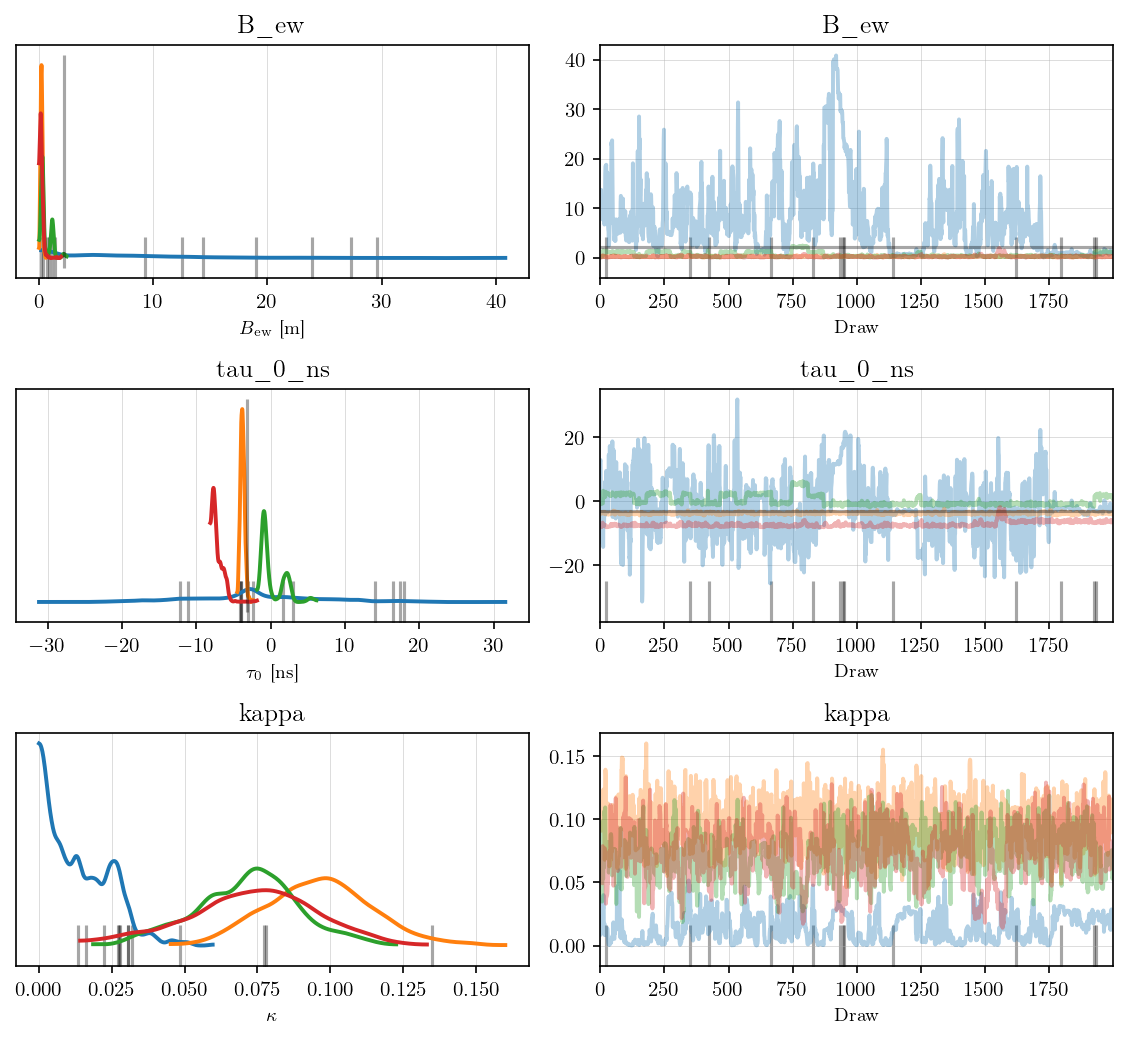

In [7]:
# Cell 7 — Trace plots (plotting.py style)
var_labels = {
    "B_ew":     r"$B_{\rm ew}$ [m]",
    "tau_0_ns": r"$\tau_0$ [ns]",
    "kappa":    r"$\kappa$",
}

axes = az.plot_trace(
    idata,
    var_names=["B_ew", "tau_0_ns", "kappa"],
    compact=False,
    figsize=(TEXTWIDTH_IN, 7),
    lines=[
        ("B_ew",      {}, idata.posterior["B_ew"].mean().item()),
        ("tau_0_ns",  {}, idata.posterior["tau_0_ns"].mean().item()),
    ],
)

for row, var in zip(axes, ["B_ew", "tau_0_ns", "kappa"]):
    row[0].set_xlabel(var_labels[var])
    row[1].set_xlabel("Draw")
    for ax in row:
        ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/arviz/plots/backends/matplotlib/kdeplot.py:166: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(x_x, y_y, density, **contour_kwargs)


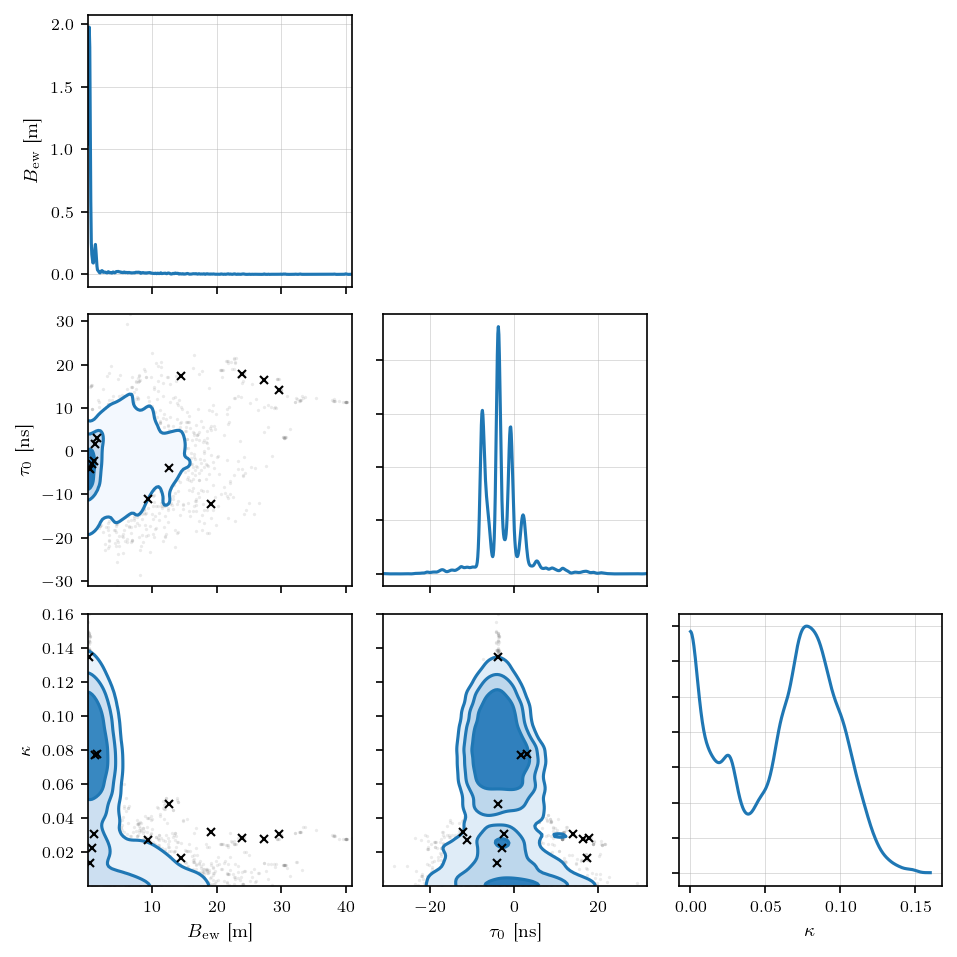

In [8]:
# Cell 8 — Corner (pair) plots (plotting.py style)
axes = az.plot_pair(
    idata,
    var_names=["B_ew", "tau_0_ns", "kappa"],
    kind=["kde", "scatter"],
    kde_kwargs={
        "contourf_kwargs": {"alpha": 0.4, "cmap": "Blues"},
        "contour_kwargs":  {"colors": PRIMARY_COLOR, "linewidths": LW_FINE},
    },
    scatter_kwargs={"alpha": 0.15, "color": NEUTRAL_COLOR, "s": SCATTER_S_FINE},
    marginals=True,
    figsize=(TEXTWIDTH_IN * 0.85, TEXTWIDTH_IN * 0.85),
    divergences=True,
    divergences_kwargs={"color": "C3", "marker": "x", "ms": 4},
    labeller=az.labels.MapLabeller(var_name_map={
        "B_ew":     r"$B_{\rm ew}$ [m]",
        "tau_0_ns": r"$\tau_0$ [ns]",
        "kappa":    r"$\kappa$",
    }),
)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9 — Posterior predictive check: sinusoidal fringe vs HA at peak channel
#
# The model predicts phase φ_model(n,k) = 2π f_k τ_tot(n).
# The expected observable is a sinusoidal fringe:
#   Re(V_dc) ≈ A · cos(φ_model)
# where A is estimated from the data (median |V_dc| at the peak channel).
# Plotting Re(V_dc) vs HA shows the sinusoid directly; plotting wrapped phase
# would produce a sawtooth (many wraps over 6°) which is harder to interpret.

# Peak channel: highest-RMS channel in signal band among selected subset
sb_mask    = (F_SKY_GHZ[ch_idx] >= 9.9) & (F_SKY_GHZ[ch_idx] <= 10.0)
vis_sb_rms = np.nanstd(np.abs(vis_sub[:, sb_mask]), axis=0)
k_sub_peak = np.where(sb_mask)[0][np.argmax(vis_sb_rms)]
k_ch_peak  = ch_idx[k_sub_peak]
F_PEAK_GHZ = F_SKY_GHZ[k_ch_peak]
print(f'PPC peak channel: k={k_ch_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')

# Observed sinusoidal fringe at peak channel (raw, not normalised)
Re_data_peak = vis_sub[:, k_sub_peak].real   # (N_cap,)
A_est        = np.nanmedian(np.abs(vis_sub[:, k_sub_peak]))   # amplitude estimate

# Draw 200 posterior samples → sinusoidal fringe A·cos(φ_model)
rng       = np.random.default_rng(0)
posterior = idata.posterior
n_chains  = posterior.dims["chain"]
n_draws   = posterior.dims["draw"]
idx_pairs = [(rng.integers(n_chains), rng.integers(n_draws)) for _ in range(200)]

f_peak_hz  = F_PEAK_GHZ * 1e9
Re_ppc     = np.zeros((200, len(ha_rad)))
for s, (ci, di) in enumerate(idx_pairs):
    B_s   = float(posterior["B_ew"].values[ci, di])
    t0_s  = float(posterior["tau_0_ns"].values[ci, di]) * 1e-9
    tau_g = (B_s / C_LIGHT) * cos_dec * sin_ha
    phase = 2 * np.pi * f_peak_hz * (tau_g + t0_s)
    Re_ppc[s] = A_est * np.cos(phase)   # sinusoidal fringe prediction

ppc_lo  = np.percentile(Re_ppc, 3,  axis=0)
ppc_hi  = np.percentile(Re_ppc, 97, axis=0)
ppc_mid = np.mean(Re_ppc, axis=0)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.5))
ax.fill_between(ha_deg, ppc_lo, ppc_hi,
                color=NEUTRAL_COLOR, alpha=0.4, label=r'94\% posterior predictive')
ax.plot(ha_deg, ppc_mid, color=SECONDARY_COLOR, lw=LW_STANDARD, label='Posterior mean')
ax.scatter(ha_deg, Re_data_peak,
           s=SCATTER_S_FINE, color=PRIMARY_COLOR, zorder=5,
           label=rf'$\mathrm{{Re}}(V_{{\rm dc}})$ — $k={k_ch_peak}$, {F_PEAK_GHZ:.4f}\,GHz')
ax.set_xlabel('Hour angle [deg]')
ax.set_ylabel(r'$\mathrm{Re}(V_{\rm dc})$')
ax.set_title(r'Posterior predictive check — sinusoidal fringe at peak channel')
ax.legend(fontsize=TICK_SIZE)
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# Cell 10 — Results summary
B_ew_mean = idata.posterior["B_ew"].mean().item()
B_ew_std  = idata.posterior["B_ew"].std().item()
B_ew_hdi  = az.hdi(idata, var_names=["B_ew"], hdi_prob=0.94)["B_ew"].values

tau0_mean = idata.posterior["tau_0_ns"].mean().item()
tau0_std  = idata.posterior["tau_0_ns"].std().item()

kappa_mean = idata.posterior["kappa"].mean().item()
sigma_phi  = 1.0 / np.sqrt(kappa_mean)   # approx phase std [rad] for high kappa

print("=" * 60)
print("BASELINE ESTIMATION RESULTS  (PyMC NUTS, Von Mises phase)")
print("=" * 60)
print(f"B_ew     = {B_ew_mean:.4f} ± {B_ew_std:.4f} m")
print(f"         94% HDI: [{B_ew_hdi[0]:.4f}, {B_ew_hdi[1]:.4f}] m")
print(f"tau_0    = {tau0_mean:.4f} ± {tau0_std:.4f} ns")
print(f"kappa    = {kappa_mean:.3f}   (σ_φ ≈ {sigma_phi:.3f} rad ≈ {np.rad2deg(sigma_phi):.1f}°)")
print("=" * 60)
print(f"FFT sanity estimate: B_ew ~ {B_fft_mean:.3f} m")
print(f"Agreement: {abs(B_ew_mean - B_fft_mean) / B_fft_mean * 100:.1f}% relative difference")

BASELINE ESTIMATION RESULTS  (PyMC NUTS, Von Mises phase)
B_ew     = 2.1709 ± 4.8721 m
         94% HDI: [0.0034, 11.0447] m
tau_0    = -3.1774 ± 5.1670 ns
kappa    = 0.064   (σ_φ ≈ 3.961 rad ≈ 227.0°)
FFT sanity estimate: B_ew ~ 18.341 m
Agreement: 88.2% relative difference
